<a href="https://colab.research.google.com/github/Jeevith252/ML_BASIC_PROJECT/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [130]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report

In [131]:
(x_train , y_train) , (x_test , y_test) = tf.keras.datasets.cifar10.load_data()

In [132]:
print(x_train.shape)
print(x_test.shape)
print(y_train[:10])

(50000, 32, 32, 3)
(10000, 32, 32, 3)
[[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]


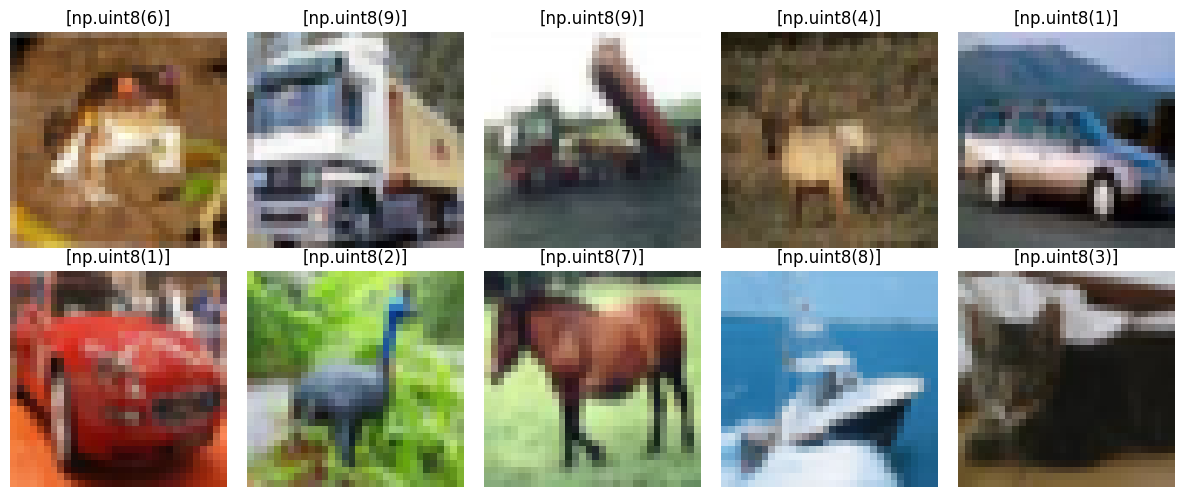

In [133]:
plt.figure(figsize=(12,5))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i])
  plt.title([y_train[i][0]])
  plt.axis("off")
plt.tight_layout()

In [134]:

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Forg",
    "Horse",
    "Ship",
    "Truck"
]

In [135]:
print(x_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [136]:
x_train = x_train / 255.0

x_test = x_test /255.0

print("Maximum : ", x_train.min())
print("Maximum : ",x_train.max())



Maximum :  0.0
Maximum :  1.0


In [137]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        units=64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        units=10,
        activation="softmax"
    )
])

In [138]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [140]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.7905 - loss: 0.5986 - val_accuracy: 0.6962 - val_loss: 0.9348
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.8051 - loss: 0.5600 - val_accuracy: 0.6938 - val_loss: 0.9380
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.8162 - loss: 0.5245 - val_accuracy: 0.7062 - val_loss: 0.9541
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.8252 - loss: 0.4938 - val_accuracy: 0.7012 - val_loss: 1.0010
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.8375 - loss: 0.4627 - val_accuracy: 0.6901 - val_loss: 1.0440
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 39ms/step - accuracy: 0.8445 - loss: 0.4370 - val_accuracy: 0.6924 - val_loss: 1.0717
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.8576 - loss: 0.4067 - val_accuracy: 0.6850 - val_loss: 1.1433
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.8623 -

In [ ]:
plt.figure(figsize = (8,5))
plt.plot(history.history["accuracy"] , label = "Training Accuracy")
plt.plot(history.history["val_accuracy"] , label = "Validation Acuuracy")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
predictions = model.predict(x_test)


predicted_label = np.argmax(predictions[0])
print("Predicted Digit : " , predicted_label)
print("Actual Digit : ", y_test[0])

In [ ]:
y_pred = np.argmax(predictions ,axis = 1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm , annot =True , fmt = "d",
            cmap = "Blues")
plt.show()

In [ ]:
print(classification_report(y_test , y_pred))

# **HOUSING PREDICTION DATA**

In [117]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [118]:
df = pd.read_csv("/content/Housing.csv")

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [120]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [121]:
binary_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_cols:
    df[col] = df[col].map({"yes":1, "no":0})

In [122]:
df = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True
)

In [123]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [124]:

X = df.drop("price", axis=1)

y = df["price"]

In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [126]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [127]:
model = Sequential([

    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),

    Dense(32, activation="relu"),

    Dense(16, activation="relu"),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [128]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["accuracy"]
)

In [112]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0000e+00 - loss: 25349389811712.0000 - val_accuracy: 0.0000e+00 - val_loss: 24781596393472.0000
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 25349381423104.0000 - val_accuracy: 0.0000e+00 - val_loss: 24781590102016.0000
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 25349373034496.0000 - val_accuracy: 0.0000e+00 - val_loss: 24781573324800.0000
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 25349356257280.0000 - val_accuracy: 0.0000e+00 - val_loss: 24781552353280.0000
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 25349326897152.0000 - val_accuracy: 0.0000e+00 - val_loss: 24781516701696.0000
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 25349284954112.0000 - val_accuracy: 0.0000e+00 - val_loss: 24781464272896.0000
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 

In [113]:
predictions = model.predict(X_test)

predictions[:10]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


array([[ 66.215935],
       [101.38833 ],
       [ 46.996883],
       [ 46.559364],
       [ 37.833054],
       [ 51.51204 ],
       [ 79.60665 ],
       [ 96.44196 ],
       [ 47.124302],
       [ 43.46792 ]], dtype=float32)

In [114]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions.flatten()
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,66.215935
1,6650000,101.388329
2,3710000,46.996883
3,6440000,46.559364
4,2800000,37.833054
5,4900000,51.512039
6,5250000,79.606651
7,4543000,96.441963
8,2450000,47.124302
9,3353000,43.467918


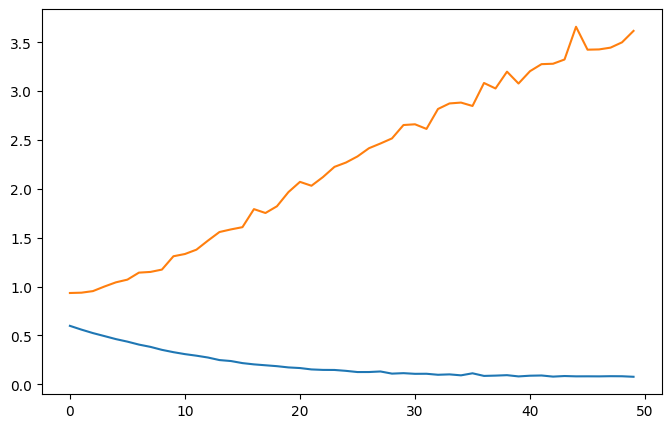

In [142]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")



plt.show()

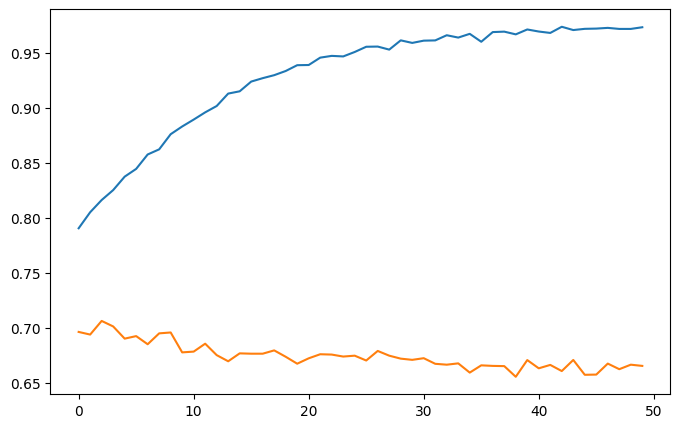

In [143]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training MAE')
plt.plot(history.history['val_accuracy'], label='Validation MAE')

plt.show()

In [144]:
import tensorflow as tf
import kagglehub
import matplotlib.pyplot as plt


dataset_path = kagglehub.dataset_download("obulisainaren/multi-cancer")

100%|██████████| 8.62G/8.62G [02:53<00:00, 53.3MB/s]

Extracting files...


In [146]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = (224,224),
    batch_size = 32
)

Found 130002 files belonging to 1 classes.
Using 104002 files for training.


In [147]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (224,224),
    batch_size = 32
)

Found 130002 files belonging to 1 classes.
Using 26000 files for validation.


In [148]:
class_names = train_ds.class_names
print("Class Found : " , class_names)

Class Found :  ['Multi Cancer']
